In [ ]:
import tensorflow as tf
from keras import layers, models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

file_path = '/content/drive/My Drive/instrunet_dataset.npz'
data = np.load(file_path, allow_pickle=True)

X_train = data["X_train"]
Y_train = data["y_train"]
X_test  = data["X_test"]
Y_test  = data["y_test"]

print(X_train.shape, Y_train.shape)

print(X_train.shape)
print(X_test.shape)

(33848, 128, 128, 1) (33848, 28)
(33848, 128, 128, 1)
(8463, 128, 128, 1)


In [ ]:
model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(28, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(X_train,Y_train, epochs=10,validation_data=(X_test,Y_test))

Epoch 1/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1823s 2s/step - accuracy: 0.6679 - loss: 0.2185 - val_accuracy: 0.9009 - val_loss: 0.0293
Epoch 2/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1791s 2s/step - accuracy: 0.9287 - loss: 0.0224 - val_accuracy: 0.9399 - val_loss: 0.0233
Epoch 3/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1758s 2s/step - accuracy: 0.9540 - loss: 0.0152 - val_accuracy: 0.9579 - val_loss: 0.0121
Epoch 4/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1763s 2s/step - accuracy: 0.9628 - loss: 0.0122 - val_accuracy: 0.9595 - val_loss: 0.0214
Epoch 5/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1742s 2s/step - accuracy: 0.9732 - loss: 0.0088 - val_accuracy: 0.9404 - val_loss: 0.0199
Epoch 6/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1754s 2s/step - accuracy: 0.9760 - loss: 0.0091 - val_accuracy: 0.9715 - val_loss: 0.0120
Epoch 7/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1762s 2s/step - accuracy: 0.9806 - loss: 0.0072 - val_accuracy: 0.9235 - val_loss: 0.1032
Epoch 8/10
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 1758s 2s/step - accuracy: 0.9809 -

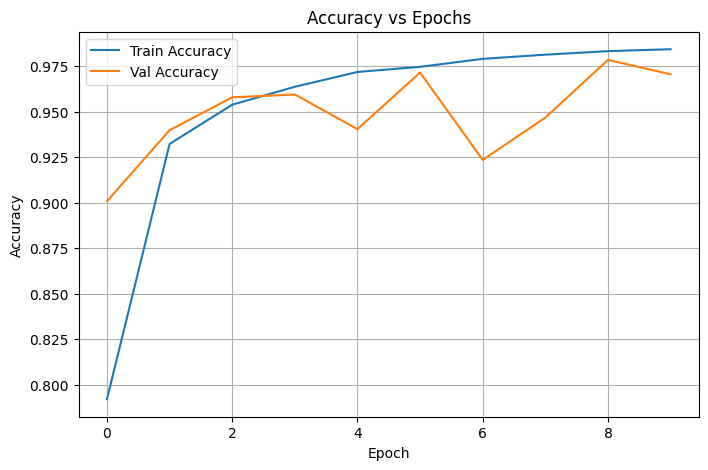

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

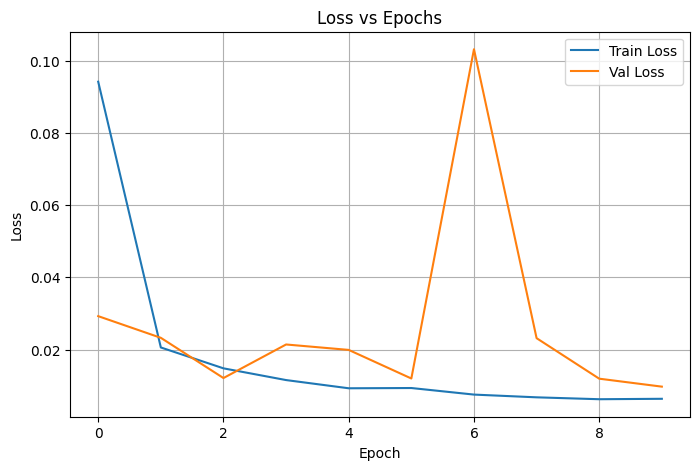

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

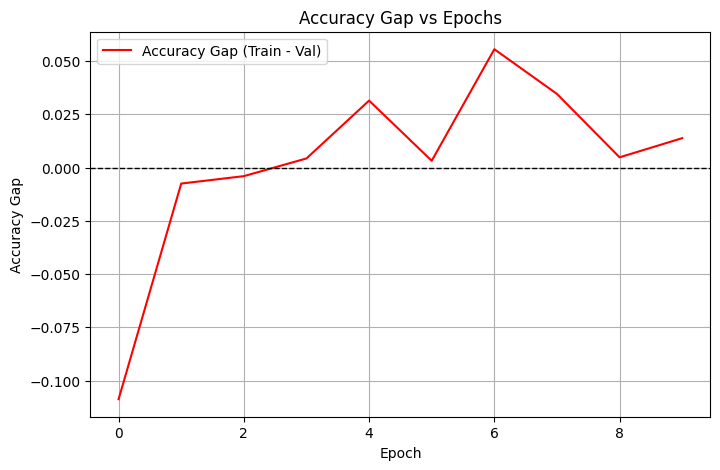

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']

acc_gap = np.array(train_acc) - np.array(val_acc)

plt.figure(figsize=(8, 5))
plt.plot(acc_gap, label='Accuracy Gap (Train - Val)', color='red')
plt.axhline(0, linestyle='--', color='black', linewidth=1)

plt.title('Accuracy Gap vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = model.predict(X_test)

265/265 ━━━━━━━━━━━━━━━━━━━━ 84s 318ms/step


In [ ]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = Y_test

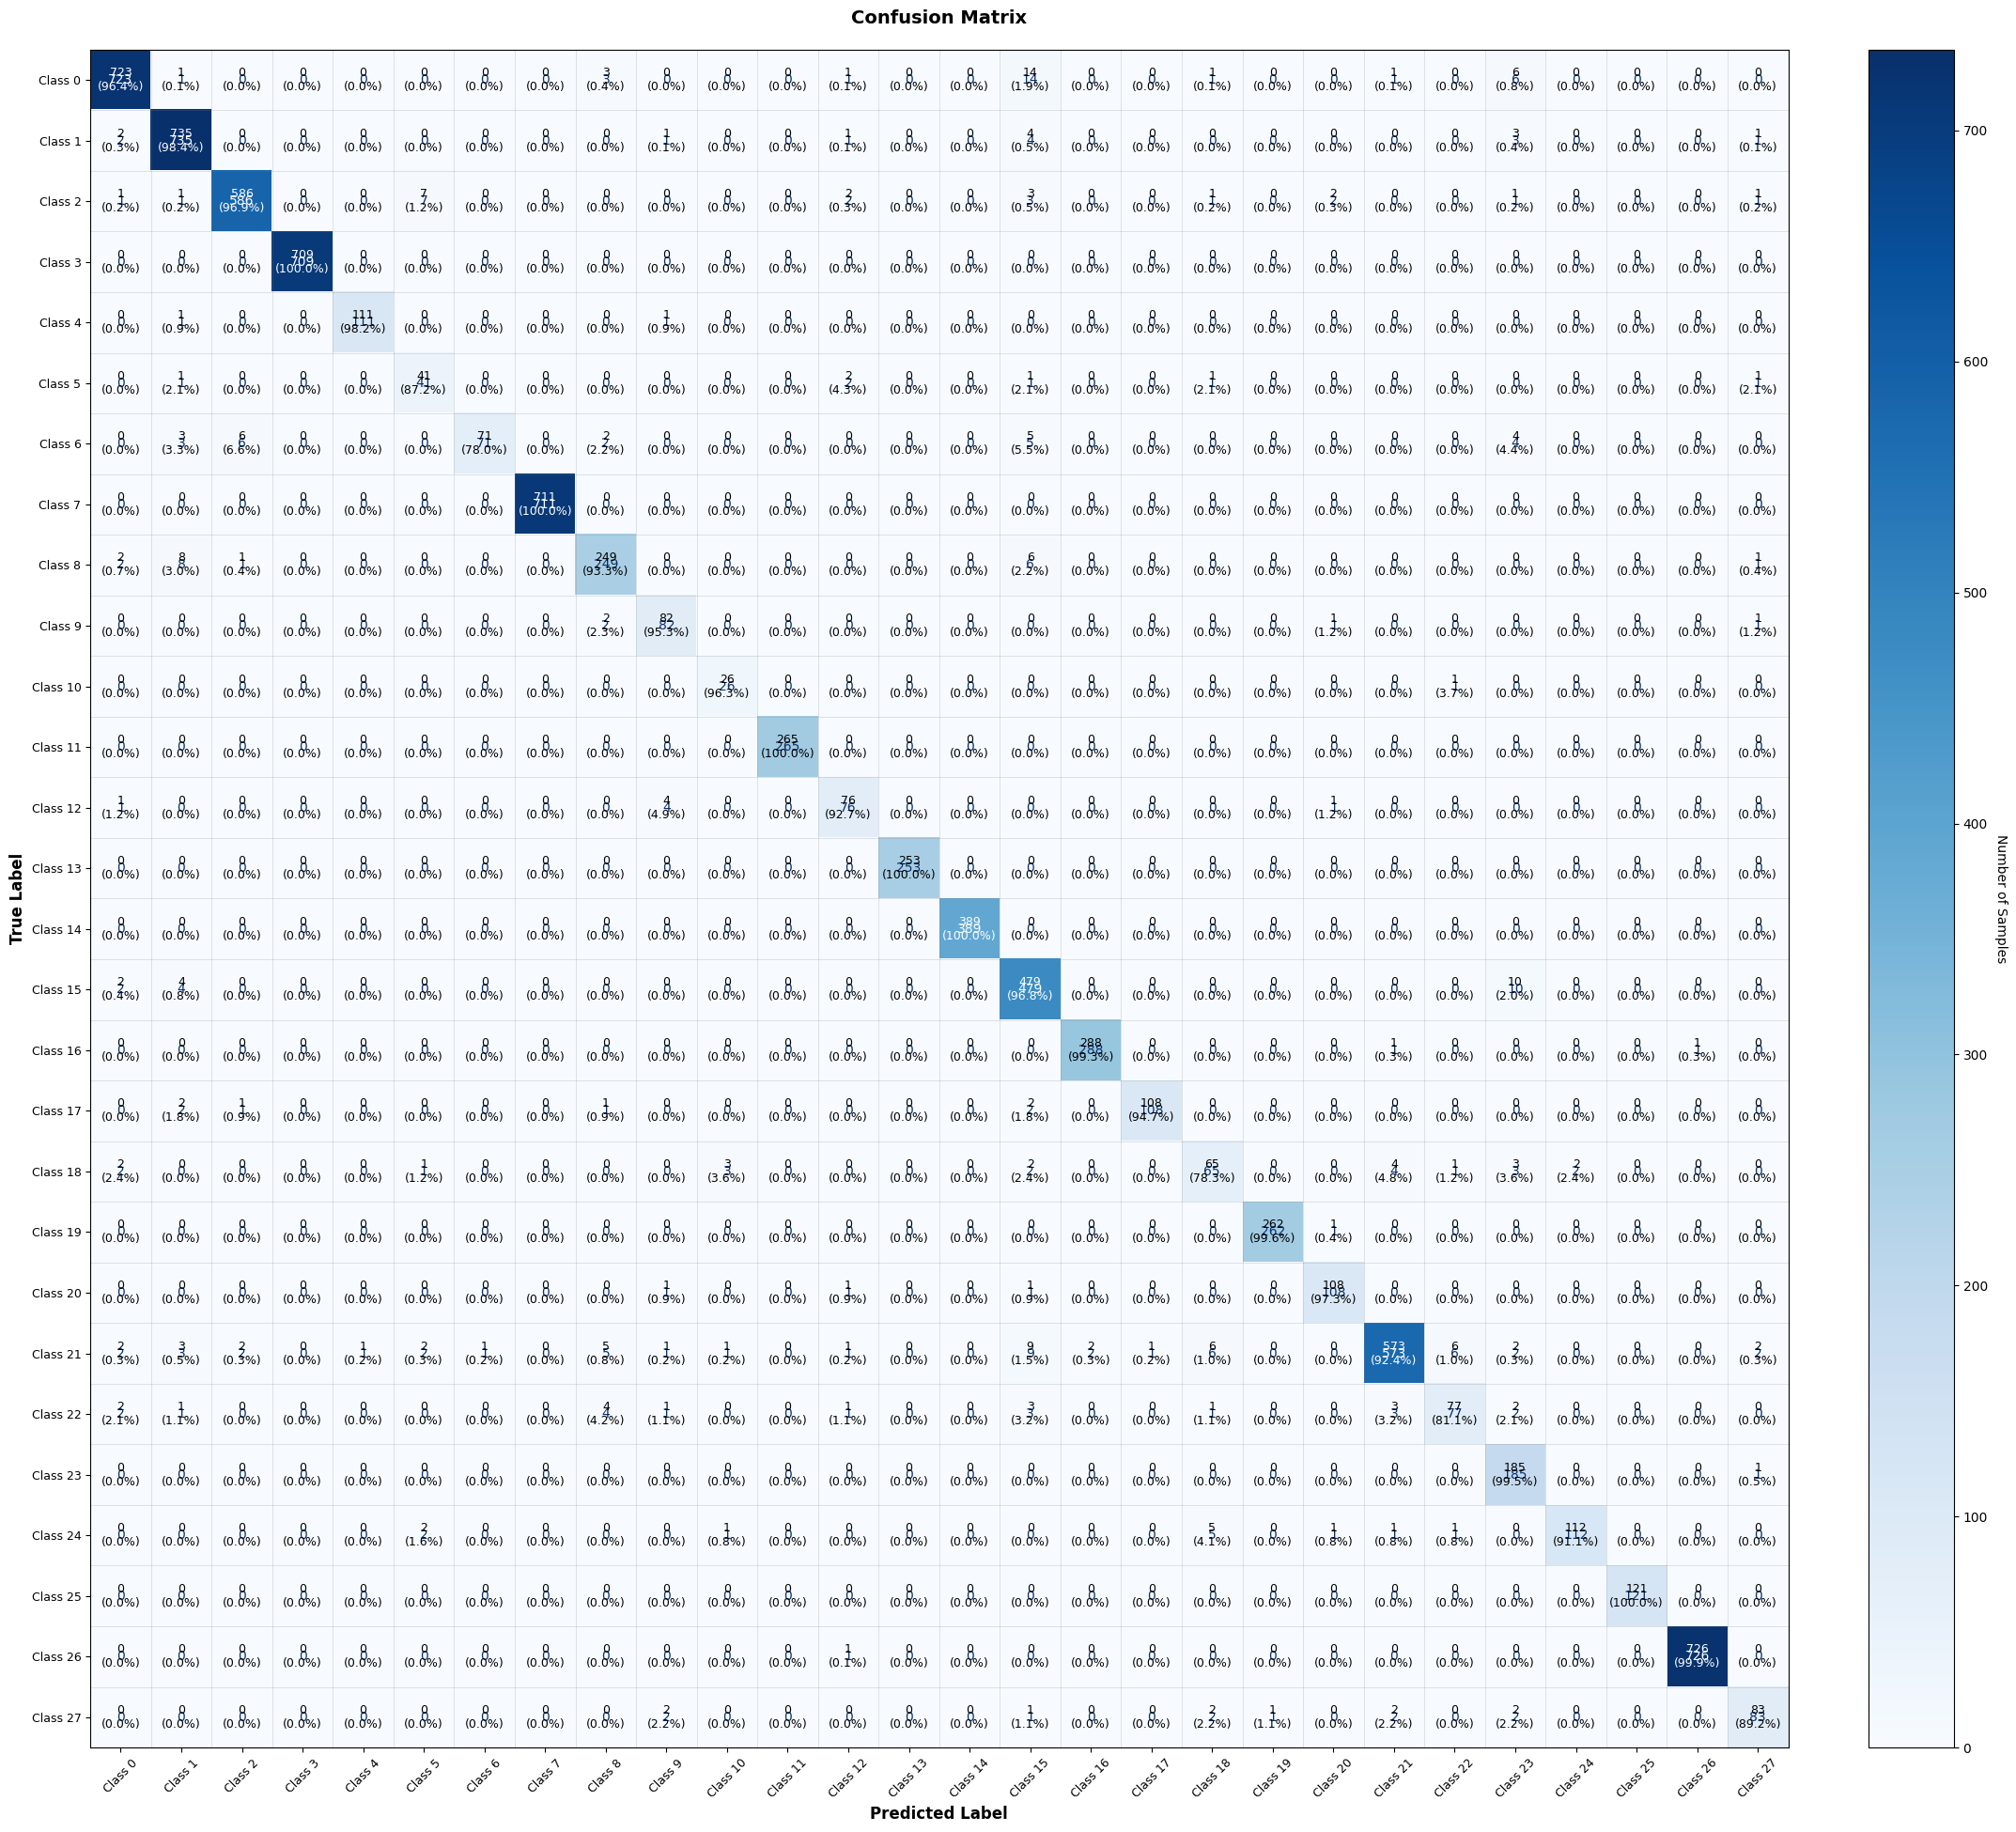


CONFUSION MATRIX SUMMARY

Overall Accuracy: 97.06%

Top 2 Best Classes:
  1. Class 25: 100.00% (121/121)
  2. Class 11: 100.00% (265/265)

Top 2 Worst Classes:
  1. Class 6: 78.02% (71/91)
  2. Class 18: 78.31% (65/83)

Most Confused Pairs:
  True 0 → Pred 15: 14 samples (1.9% of class 0)
  True 15 → Pred 23: 10 samples (2.0% of class 15)
  True 21 → Pred 15: 9 samples (1.5% of class 21)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

if y_true_classes.ndim > 1:
    y_true_classes = np.argmax(y_true_classes, axis=1)

if y_pred_classes.ndim > 1:
    y_pred_classes = np.argmax(y_pred_classes, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
num_classes = cm.shape[0]

fig, ax = plt.subplots(figsize=(max(8, num_classes*0.8), max(6, num_classes*0.7)))

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[f'Class {i}' for i in range(num_classes)])

im = disp.plot(ax=ax, cmap="Blues",
               values_format='d',
               colorbar=False,
               xticks_rotation=45)

thresh = cm.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        count = cm[i, j]
        percent = cm_percent[i, j] if not np.isnan(cm_percent[i, j]) else 0

        text = f'{count}\n({percent:.1f}%)'

        color = 'white' if cm[i, j] > thresh else 'black'

        ax.text(j, i, text,
                ha='center', va='center',
                color=color, fontsize=9,
                linespacing=1.2)

cbar = plt.colorbar(im.im_, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of Samples', rotation=270, labelpad=15)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=20)

ax.tick_params(axis='both', which='major', labelsize=9)

ax.set_xticks(np.arange(num_classes+1)-0.5, minor=True)
ax.set_yticks(np.arange(num_classes+1)-0.5, minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.tick_params(which='minor', size=0)

plt.tight_layout()

plt.show()

print("\n" + "="*50)
print("CONFUSION MATRIX SUMMARY")
print("="*50)

class_accuracies = np.diag(cm) / cm.sum(axis=1)
overall_accuracy = np.trace(cm) / np.sum(cm)

print(f"\nOverall Accuracy: {overall_accuracy:.2%}")

sorted_indices = np.argsort(class_accuracies)[::-1]
print(f"\nTop 2 Best Classes:")
for rank, idx in enumerate(sorted_indices[:2], 1):
    print(f"  {rank}. Class {idx}: {class_accuracies[idx]:.2%} ({cm[idx, idx]}/{cm.sum(axis=1)[idx]})")

print(f"\nTop 2 Worst Classes:")
for rank, idx in enumerate(sorted_indices[-2:][::-1], 1):
    print(f"  {rank}. Class {idx}: {class_accuracies[idx]:.2%} ({cm[idx, idx]}/{cm.sum(axis=1)[idx]})")

if num_classes > 1:
    confusion_pairs = []
    for i in range(num_classes):
        for j in range(num_classes):
            if i != j and cm[i, j] > 0:
                confusion_pairs.append(((i, j), cm[i, j]))

    if confusion_pairs:
        confusion_pairs.sort(key=lambda x: x[1], reverse=True)
        print(f"\nMost Confused Pairs:")
        for (i, j), count in confusion_pairs[:3]:
            percent_of_i = cm[i, j] / cm[i].sum() * 100
            print(f"  True {i} → Pred {j}: {count} samples ({percent_of_i:.1f}% of class {i})")
    else:
        print("\nNo misclassifications found (perfect classifier!)")

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0097
Test Accuracy: 0.9706


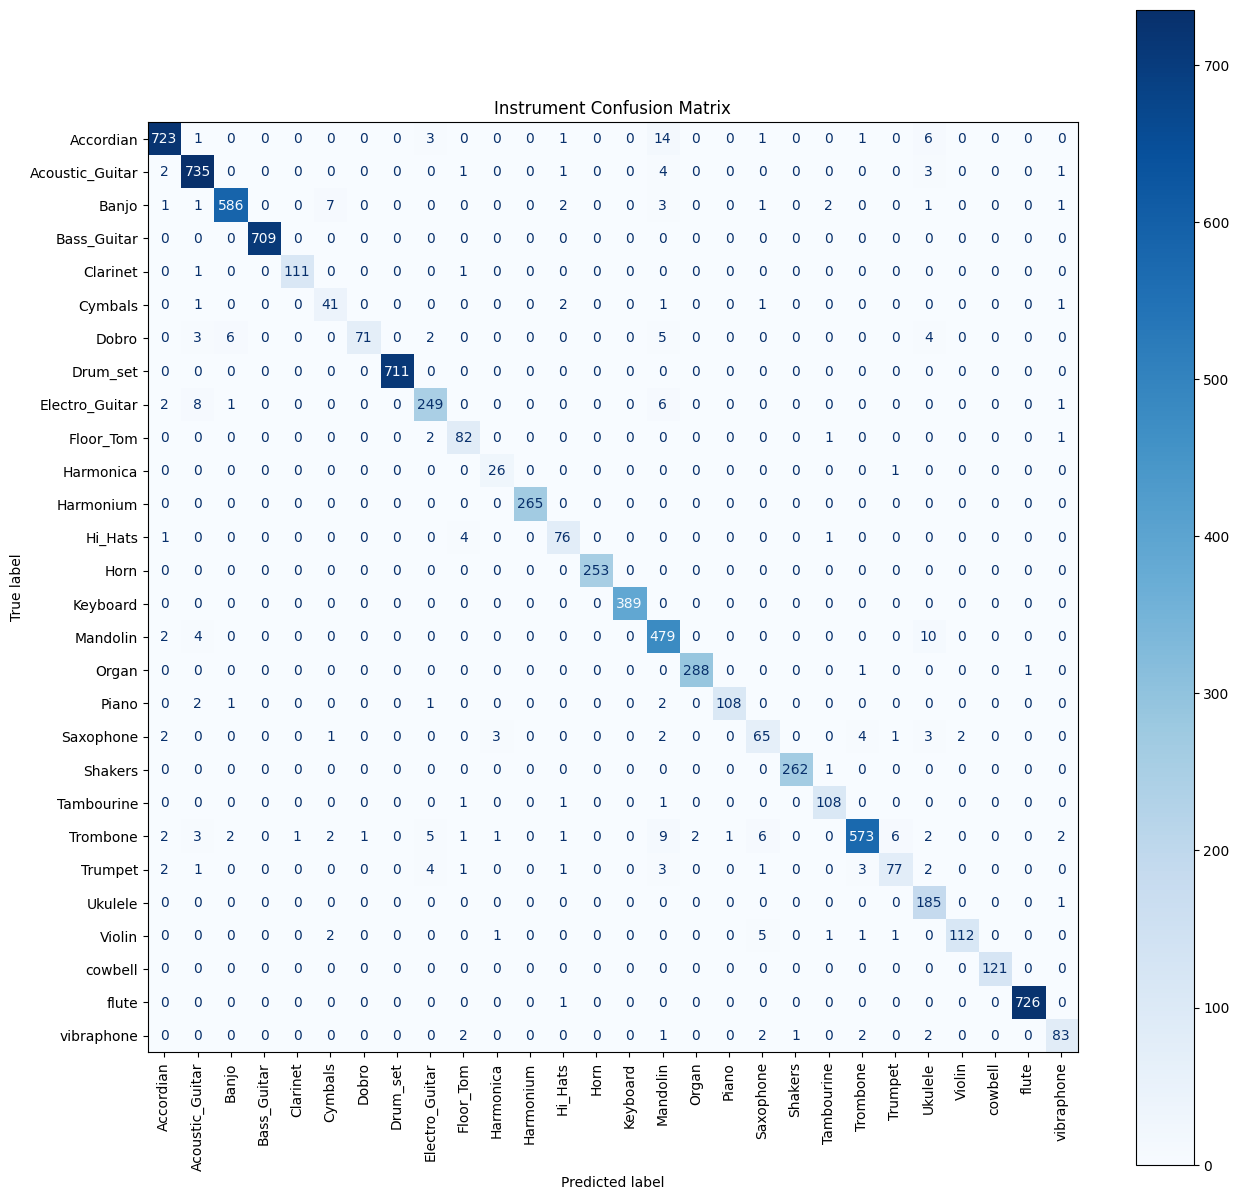

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ['Accordian','Acoustic_Guitar','Banjo','Bass_Guitar','Clarinet','Cymbals','Dobro','Drum_set','Electro_Guitar','Floor_Tom','Harmonica','Harmonium','Hi_Hats','Horn','Keyboard','Mandolin','Organ','Piano','Saxophone','Shakers','Tambourine','Trombone','Trumpet','Ukulele','Violin','cowbell','flute','vibraphone']

fig, ax = plt.subplots(figsize=(15, 15))

cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')

plt.title("Instrument Confusion Matrix")
plt.show()

In [ ]:
model.save("instruNet_model_final.keras")